## Exploratory Data Analysis

## Part 1: Load data and basic overview

In [3]:
#import libraries
import pandas as pd

#load dataset
df = pd.read_csv('../data_clean/master_dataset.csv')

In [4]:
#basic preview
df.head()

,la_code,borough,gld,fsm,sen,idaci,ofsted,total_places,under5,childcare_per_100,ethnic_diversity
0,E09000007,Camden,68.3,46.67,17.681992,0.182241,1.851187,3286,9934,33.078317,0.953160
1,E09000001,City of London,84.2,21.93,11.488783,0.054000,1.866279,344,215,160.000000,0.937560
2,E09000012,Hackney,69.5,44.66,19.183618,0.255382,1.862452,5489,16247,33.784699,0.957100
3,E09000013,Hammersmith and Fulham,66.9,34.50,17.610787,0.181938,1.826860,3038,9237,32.889466,0.948323
4,E09000014,Haringey,73.2,31.09,17.629577,0.201324,1.993649,4409,14962,29.467986,0.956283


In [5]:
#basic preview
df.describe()

,gld,fsm,sen,idaci,ofsted,total_places,under5,childcare_per_100,ethnic_diversity
count,33.000000,33.000000,33.000000,33.000000,33.000000,33.000000,33.000000,33.000000,33.000000
mean,69.503030,30.654242,16.660639,0.168070,1.915760,4823.878788,15923.000000,35.114967,0.944567
std,3.779921,9.601618,2.493281,0.053267,0.088671,1575.044558,5615.862306,23.301486,0.024143
min,64.800000,15.060000,11.488783,0.054000,1.665714,344.000000,215.000000,19.470513,0.886308
25%,66.900000,22.760000,14.862947,0.125641,1.866279,3808.000000,11913.000000,27.504757,0.945257
50%,69.100000,31.090000,16.623858,0.163697,1.916741,5001.000000,16621.000000,32.105490,0.952454
75%,70.500000,36.360000,18.333231,0.201324,1.978600,5597.000000,18913.000000,33.784699,0.958713
max,84.200000,49.690000,22.219987,0.268195,2.076976,8144.000000,25263.000000,160.000000,0.972846


In [6]:
#confirm 
df[df['childcare_per_100']>100]

,la_code,borough,gld,fsm,sen,idaci,ofsted,total_places,under5,childcare_per_100,ethnic_diversity
1,E09000001,City of London,84.2,21.93,11.488783,0.054,1.866279,344,215,160.0,0.93756


In [7]:
#outlier for city of London
df['city_of_london_flag'] = (
    df['borough'] == 'City of London'
).astype(int)

#### VISUALISATION

In [12]:
#import libraries
import matplotlib.pyplot as plt
import numpy as np

In [13]:
#define variables
variables = ['fsm', 'sen', 'idaci', 'ofsted', 'total_places', 'under5', 'childcare_per_100', 'ethnic_diversity']

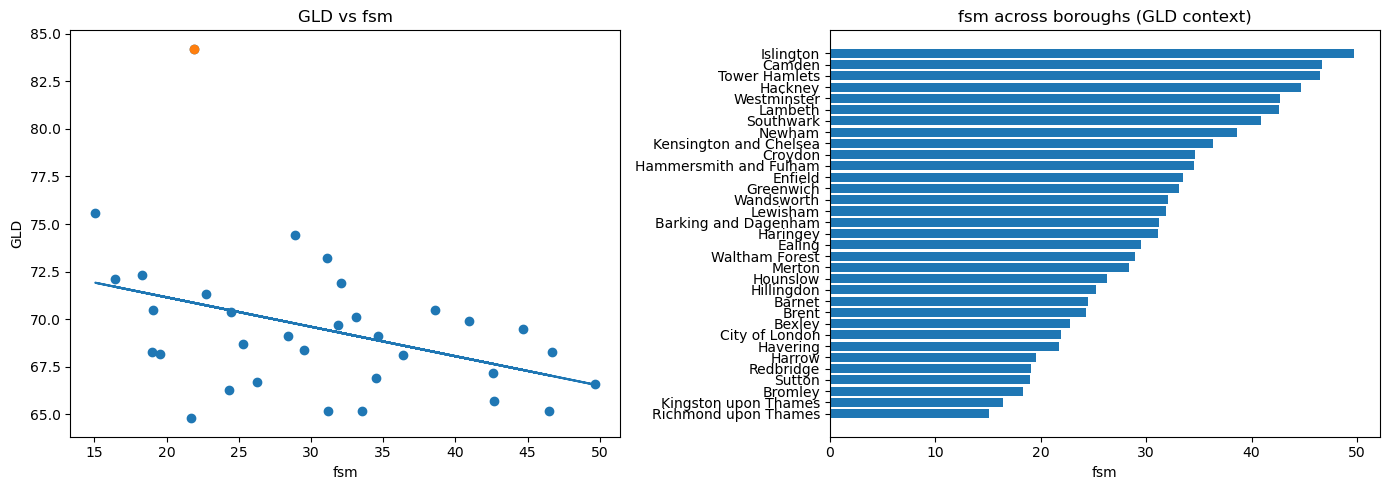

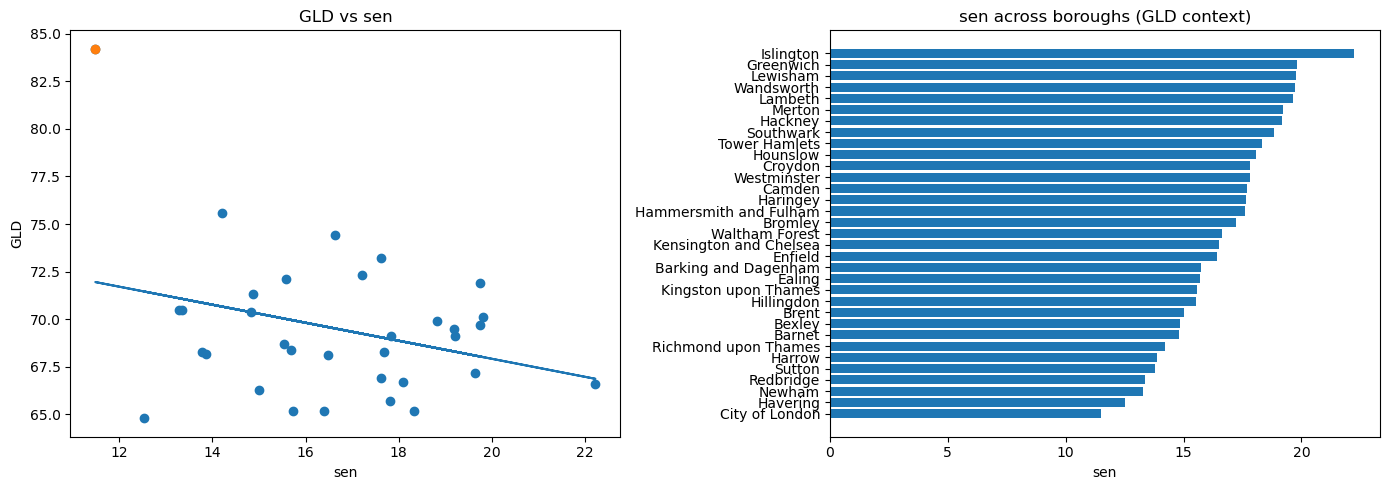

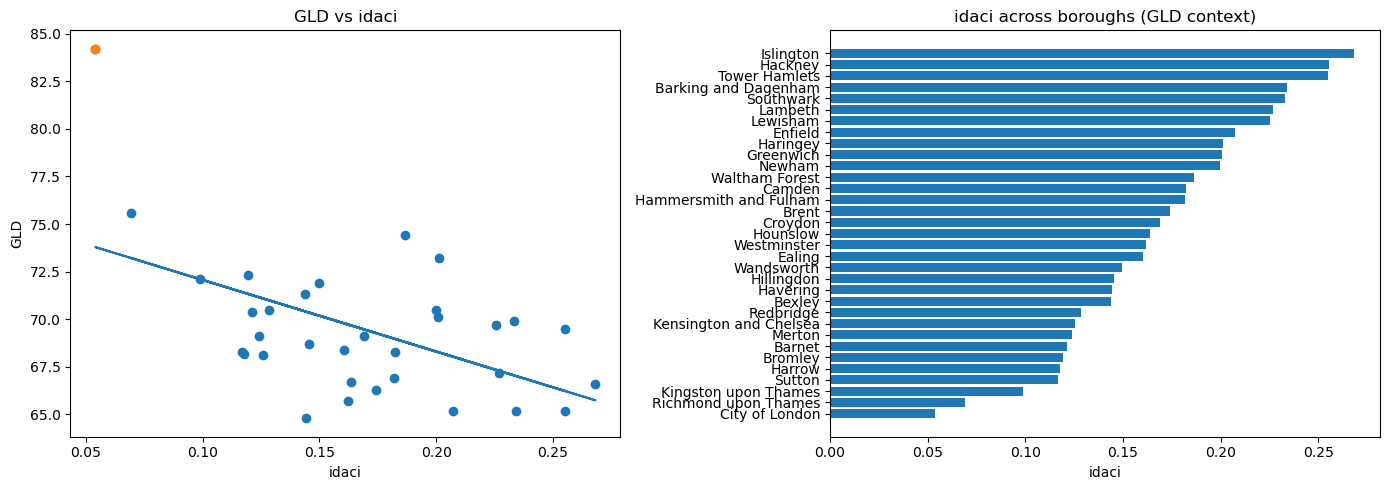

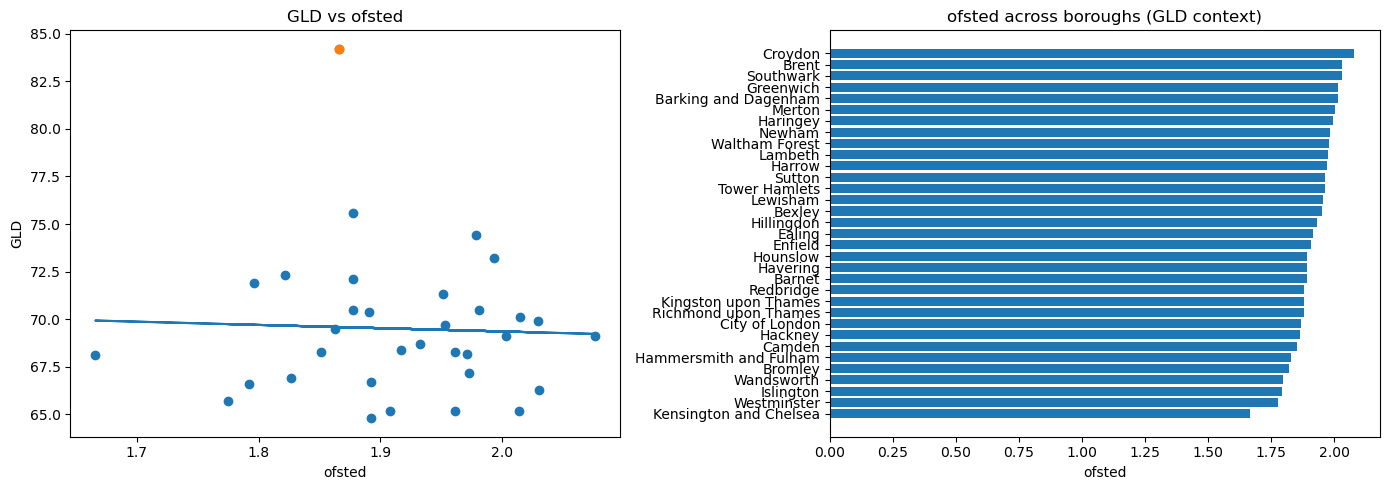

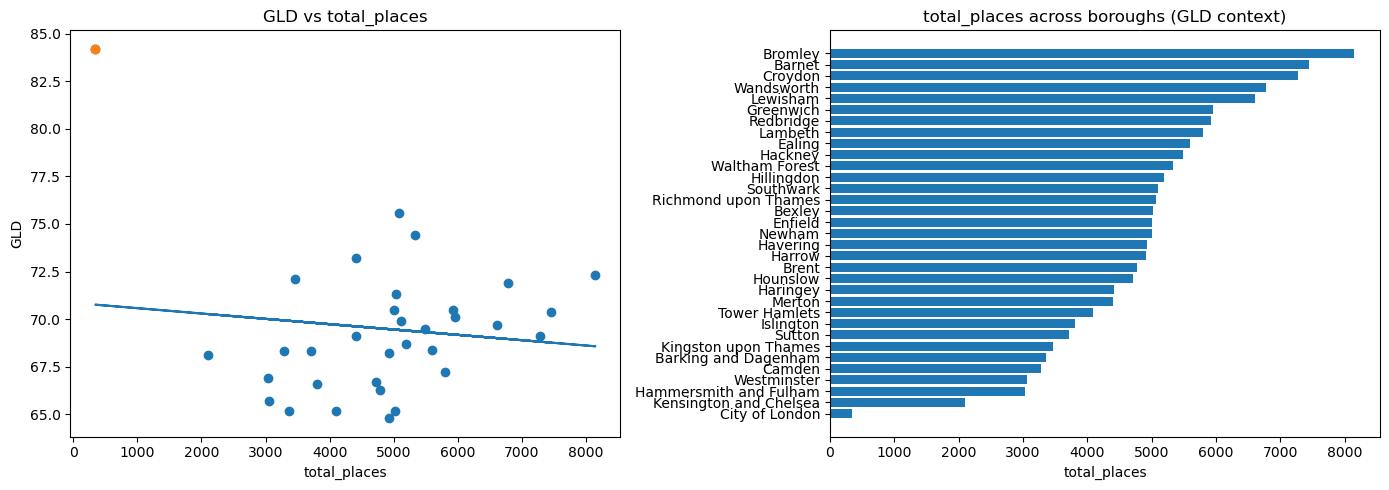

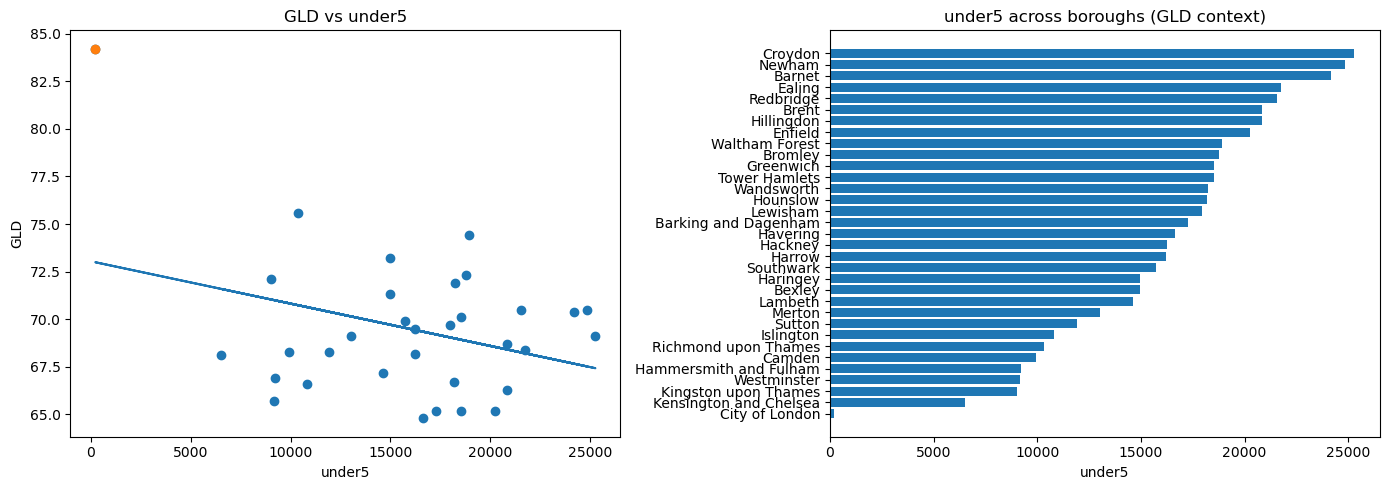

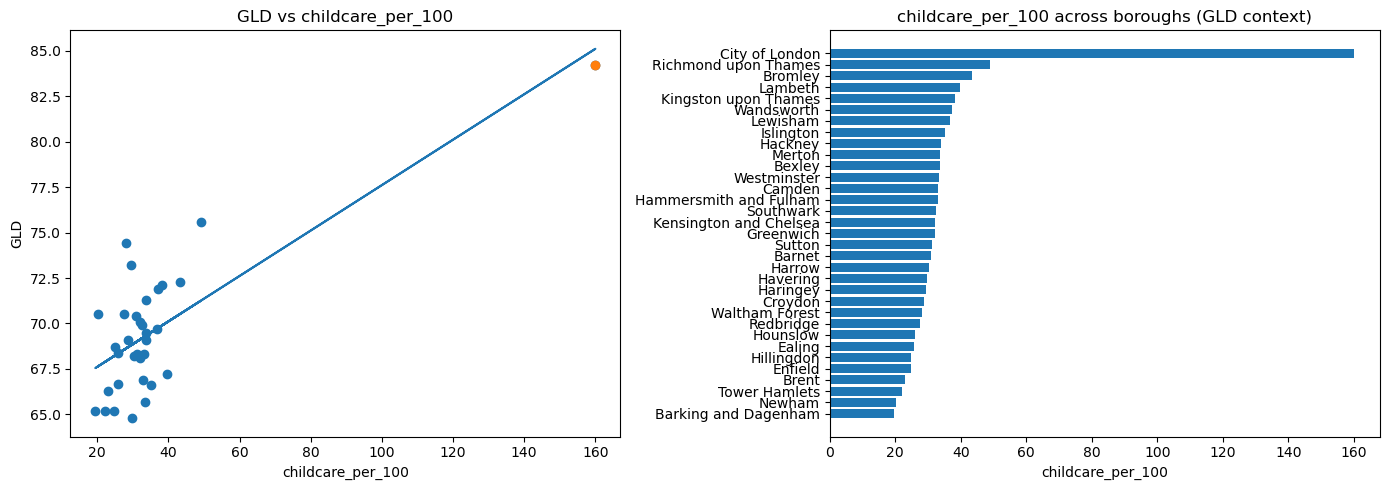

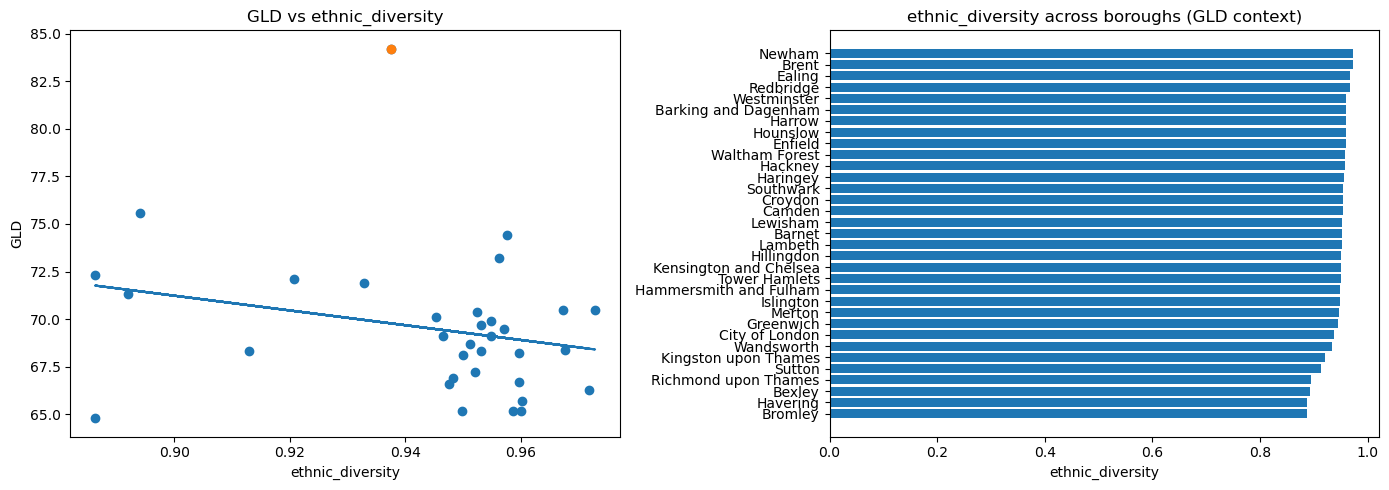

In [16]:
#create side by side visualisations
for var in variables:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    x = df[var]
    y = df['gld']
    axes[0].scatter(x, y)
    col = df[df['borough'] == 'City of London']
    axes[0].scatter(col[var], col['gld'])
    z = np.polyfit(x, y, 1)
    p = np.poly1d(z)
    axes[0].plot(x, p(x))
    axes[0].set_xlabel(var)
    axes[0].set_ylabel('GLD')
    axes[0].set_title(f'GLD vs {var}')
    
    df_sorted = df.sort_values(by=var)
    axes[1].barh(df_sorted['borough'], df_sorted[var])
    axes[1].set_title(f'{var} across boroughs (GLD context)')
    axes[1].set_xlabel(var)
    
    plt.tight_layout()
    plt.show()